In [43]:
import pandas as pd

df = pd.read_csv('Tweets.csv')

df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


STEP 1: Clean and Prepare Data

In [44]:
# Keep only useful columns
df = df[['text', 'airline_sentiment', 'tweet_created']]

# Rename for clarity
df.columns = ['text', 'sentiment', 'date']

df.head()

,text,sentiment,date
0,@VirginAmerica What @dhepburn said.,neutral,2015-02-24 11:35:52 -0800
1,@VirginAmerica plus you've added commercials t...,positive,2015-02-24 11:15:59 -0800
2,@VirginAmerica I didn't today... Must mean I n...,neutral,2015-02-24 11:15:48 -0800
3,@VirginAmerica it's really aggressive to blast...,negative,2015-02-24 11:15:36 -0800
4,@VirginAmerica and it's a really big bad thing...,negative,2015-02-24 11:14:45 -0800


STEP 2: Convert Sentiment to Numeric

In [45]:
def convert_sentiment(x):
    if x == 'positive':
        return 1
    elif x == 'neutral':
        return 0
    else:
        return -1

df.loc[:, 'sentiment_score'] = df['sentiment'].apply(convert_sentiment)


STEP 3: Extract Time 

In [46]:
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour

STEP 4: Sentiment vs Time

In [47]:
hourly_sentiment = df.groupby('hour')['sentiment_score'].mean()
hourly_sentiment


hour
0    -0.633588
1    -0.648649
2    -0.517241
3    -0.502222
4    -0.483696
5    -0.515723
6    -0.471820
7    -0.443299
8    -0.429806
9    -0.432379
10   -0.377339
11   -0.423935
12   -0.416262
13   -0.455556
14   -0.477886
15   -0.470812
16   -0.468665
17   -0.409814
18   -0.460719
19   -0.579259
20   -0.481728
21   -0.532558
22   -0.619863
23   -0.632124
Name: sentiment_score, dtype: float64

STEP 5: Visualization 

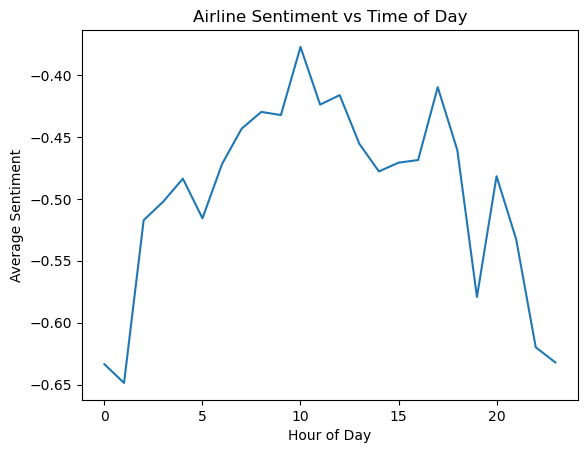

In [48]:
import matplotlib.pyplot as plt

plt.plot(hourly_sentiment.index, hourly_sentiment.values)
plt.xlabel("Hour of Day")
plt.ylabel("Average Sentiment")
plt.title("Airline Sentiment vs Time of Day")
plt.show()


STEP 6: Create Time Zones

In [49]:
def time_zone(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df.loc[:, 'time_zone'] = df['hour'].apply(time_zone)

STEP 7: Risk Score

In [50]:
def risk_score(row):
    if row['time_zone'] == "Night" and row['sentiment_score'] == -1:
        return 1  # High risk
    return 0

df.loc[:, 'risk_score'] = df.apply(risk_score, axis=1)

STEP 8: Analyze Risk

In [51]:
risk_analysis = df.groupby('time_zone')['risk_score'].mean()
risk_analysis


time_zone
Afternoon    0.000000
Evening      0.000000
Morning      0.000000
Night        0.686078
Name: risk_score, dtype: float64

STEP 9: Add Time Zone Analysis

In [52]:
zone_sentiment = df.groupby('time_zone')['sentiment_score'].mean()
zone_sentiment


time_zone
Afternoon   -0.457944
Evening     -0.487235
Morning     -0.433952
Night       -0.561580
Name: sentiment_score, dtype: float64

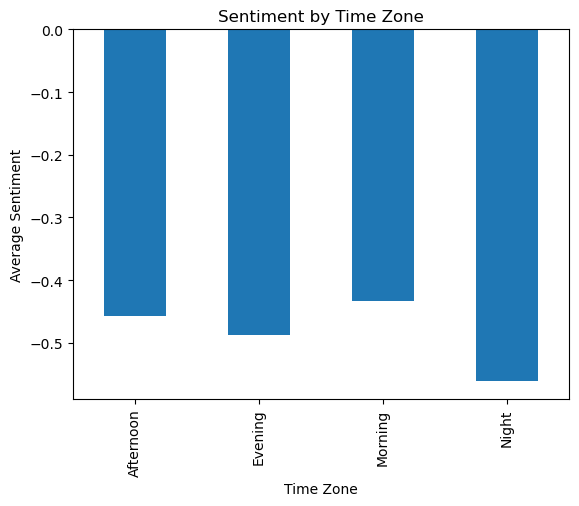

In [53]:
zone_sentiment.plot(kind='bar')
plt.title("Sentiment by Time Zone")
plt.xlabel("Time Zone")
plt.ylabel("Average Sentiment")
plt.show()


STEP 10: Risk Score Visualization 

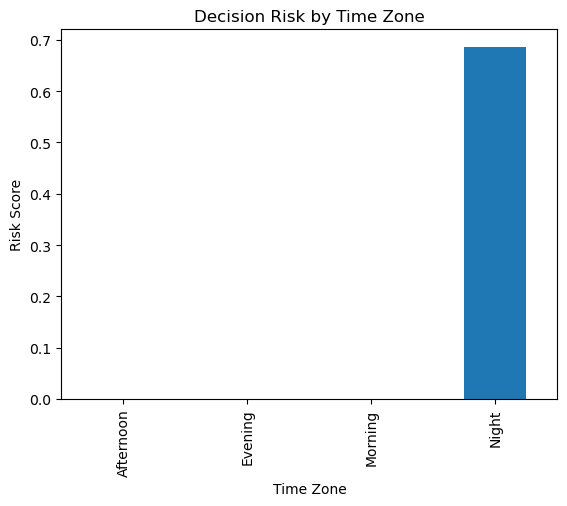

In [54]:
risk_analysis = df.groupby('time_zone')['risk_score'].mean()

risk_analysis.plot(kind='bar')
plt.title("Decision Risk by Time Zone")
plt.xlabel("Time Zone")
plt.ylabel("Risk Score")
plt.show()

STEP 11: Volume Insight

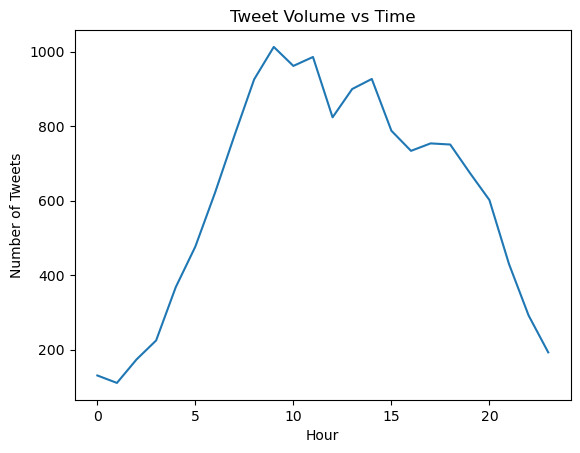

In [55]:
tweet_volume = df.groupby('hour').size()

plt.plot(tweet_volume.index, tweet_volume.values)
plt.title("Tweet Volume vs Time")
plt.xlabel("Hour")
plt.ylabel("Number of Tweets")
plt.show()


📊 Key Findings:

~ Negative sentiment peaks during late-night hours (10 PM – 3 AM)

~ Morning hours show relatively stable and less negative sentiment

~ High tweet volume combined with negative sentiment indicates higher emotional activity at night

~ A custom “Decision Risk Score” highlights night-time as a high-risk decision window


STEP 12: Top Negative Words

In [56]:
from collections import Counter
import re

negative_text = df[df['sentiment_score'] == -1]['text']

words = []
for text in negative_text:
    words += re.findall(r'\w+', text.lower())

common_words = Counter(words).most_common(20)
common_words


[('to', 6048),
 ('i', 4565),
 ('the', 4114),
 ('a', 3188),
 ('flight', 2943),
 ('united', 2899),
 ('and', 2825),
 ('on', 2792),
 ('you', 2722),
 ('for', 2714),
 ('my', 2407),
 ('usairways', 2375),
 ('t', 2263),
 ('americanair', 2110),
 ('is', 2109),
 ('in', 1783),
 ('it', 1656),
 ('of', 1529),
 ('not', 1357),
 ('your', 1352)]

In [60]:
df.to_csv("final_data.csv", index=False)